# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

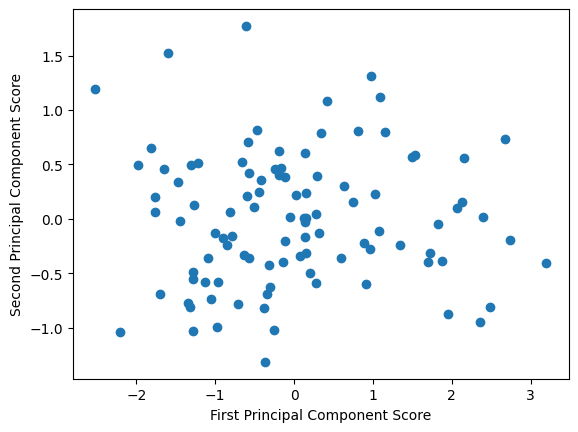

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

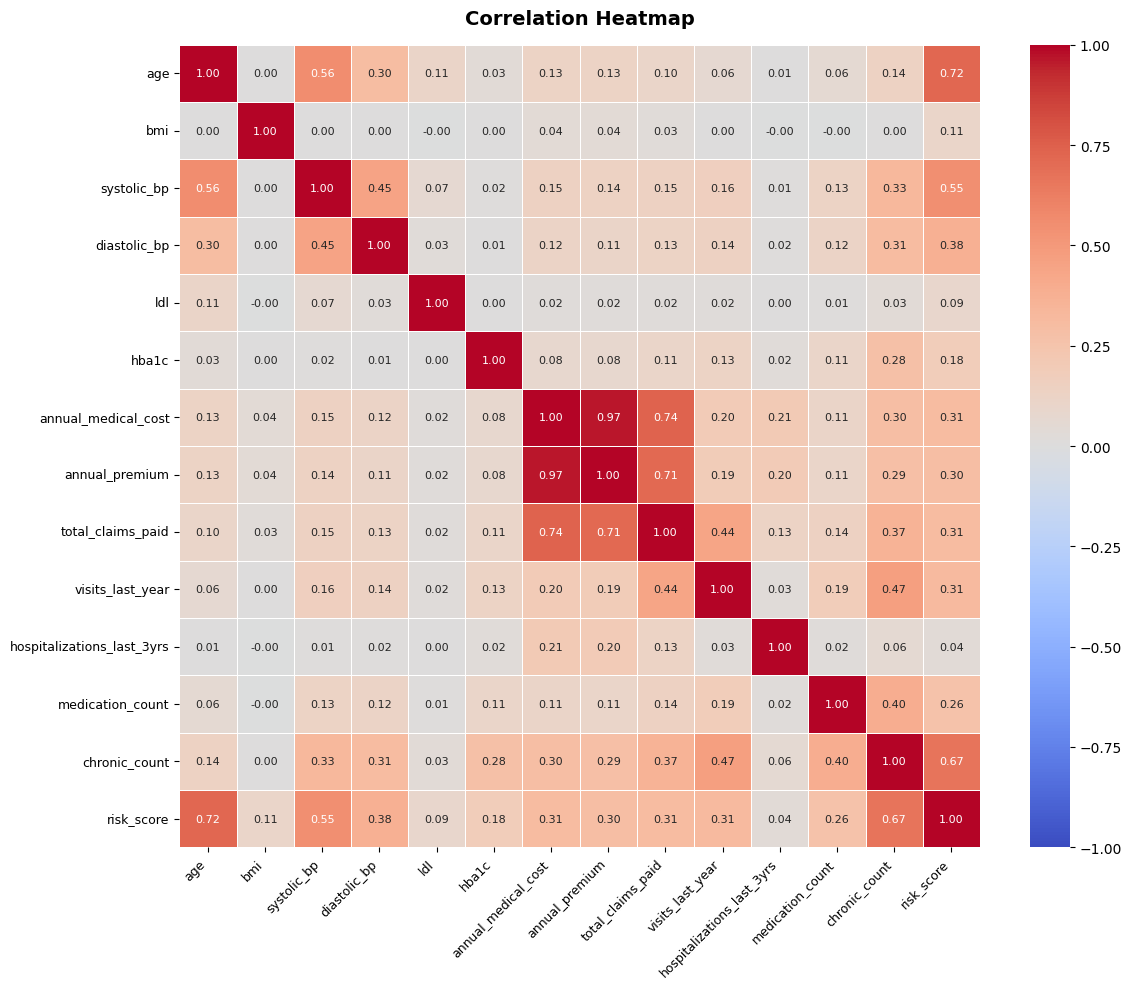

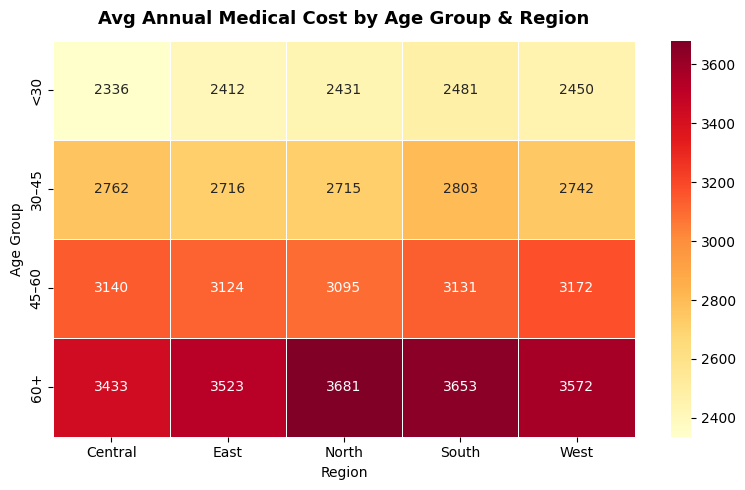

In [5]:
# Heat map

# Import seaborn
import seaborn as sns

# Load data
df = pd.read_csv('medical_insurance.csv')
 
# Select numeric features for correlation 
cols = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
    'annual_medical_cost', 'annual_premium', 'total_claims_paid',
    'visits_last_year', 'hospitalizations_last_3yrs', 'medication_count',
    'chronic_count', 'risk_score'
]
 
corr = df[cols].corr()  # Pearson correlation matrix (-1 to 1)
 
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
 
sns.heatmap(
    corr,
    annot=True,          # show correlation values in each cell
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # blue = negative, red = positive correlation
    center=0,            # white = no correlation
    vmin=-1, vmax=1,     # fix scale to full correlation range
    linewidths=0.5,      # thin grid lines between cells
    ax=ax,
    annot_kws={'size': 8}
)
 
ax.set_title('Correlation Heatmap',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_medical.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# Pivot heatmap (avg cost by age group × region) ──────────────────
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100],
                         labels=['<30', '30–45', '45–60', '60+'])
 
pivot = df.pivot_table(
    values='annual_medical_cost',
    index='age_group',
    columns='region',
    aggfunc='mean'
)
 
fig2, ax2 = plt.subplots(figsize=(8, 5))
 
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',           # no decimals for dollar amounts
    cmap='YlOrRd',       # yellow → orange → red (low → high cost)
    linewidths=0.5,
    ax=ax2
)
 
ax2.set_title('Avg Annual Medical Cost by Age Group & Region',
              fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Region')
ax2.set_ylabel('Age Group')
plt.tight_layout()
plt.savefig('heatmap_pivot.png', dpi=150, bbox_inches='tight')
plt.show()

PC1 captures : 22.6% of variance
PC1+PC2      : 34.5% of variance
PCs for 90%  : 12

Top PC1 contributors:
total_claims_paid      0.378557
annual_medical_cost    0.354669
annual_premium         0.347620
risk_score             0.328910
chronic_count          0.318837
avg_claim_amount       0.292603
Name: PC1, dtype: float64

PC1-only reconstruction MSE: 0.7739

Outliers (top 1%): 1000 points

R² scores:
                     Health indicators  Utilisation  All numeric  PC1 score only
annual_medical_cost           0.098236     0.096626     0.939285        0.568912
annual_premium                0.091860     0.090179     1.000000        0.546521
risk_score                    0.859602     0.153247     1.000000        0.489274


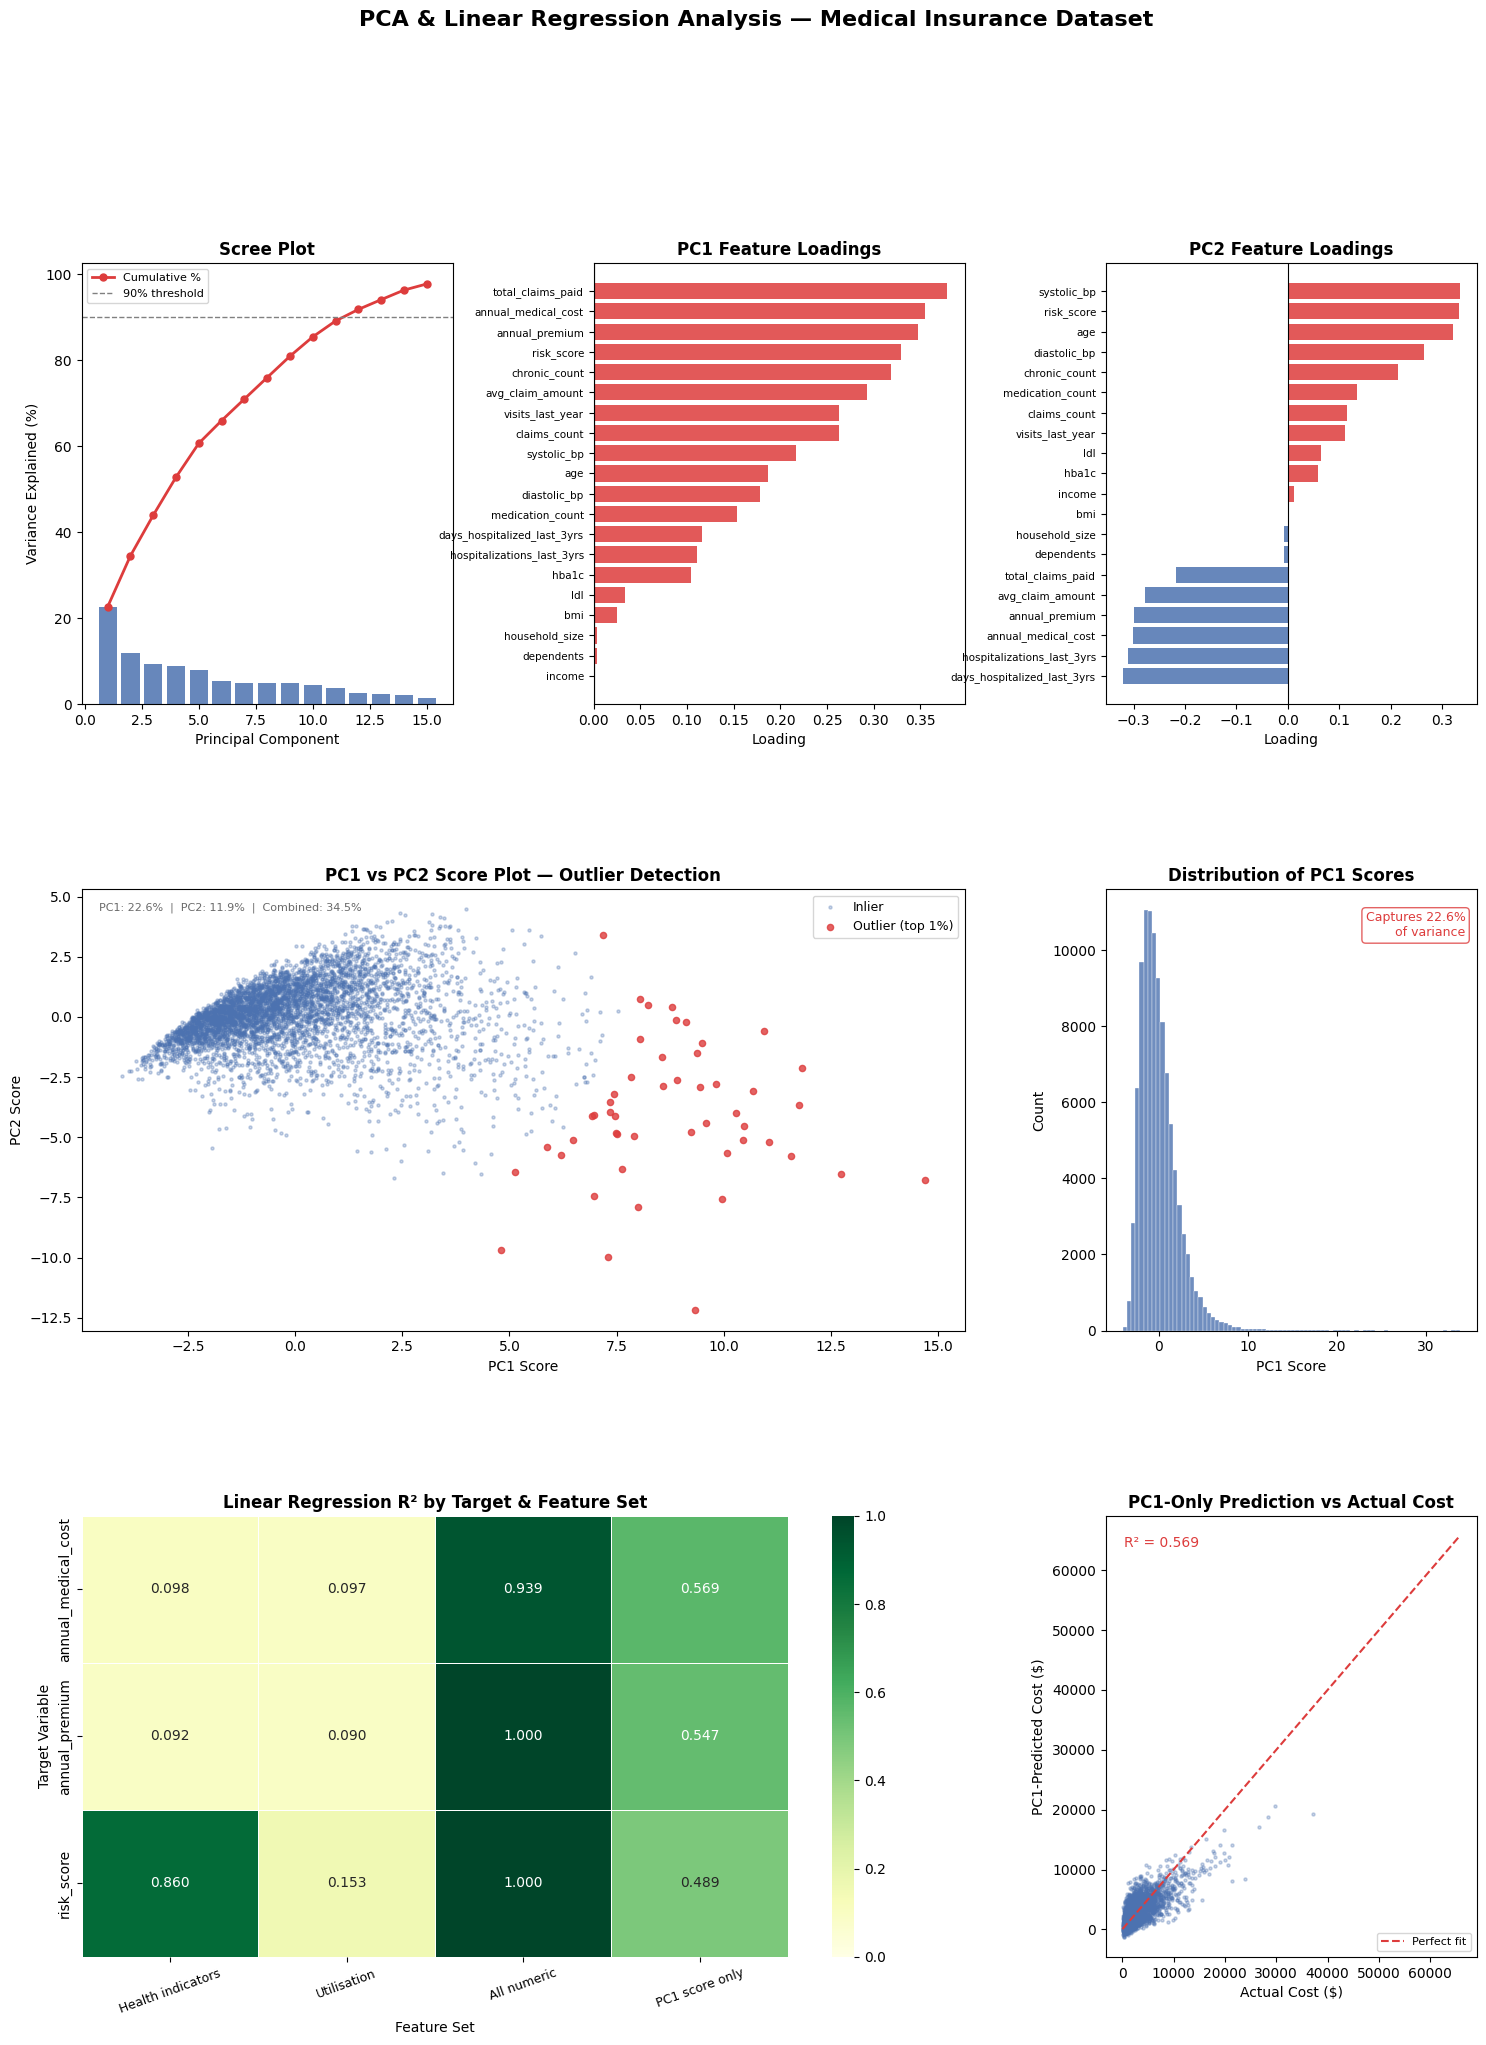

Saved: pca_regression_analysis.png


In [6]:

# Principle Component Analysis

# Imports
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Prepare Data
df = pd.read_csv('medical_insurance.csv')

# Select continuous numeric features (drop IDs, binary flags)
num_cols = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
    'income', 'household_size', 'dependents',
    'visits_last_year', 'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs', 'medication_count',
    'chronic_count', 'risk_score',
    'annual_medical_cost', 'annual_premium', 'total_claims_paid',
    'claims_count', 'avg_claim_amount'
]

data = df[num_cols].dropna()

# Standardise: PCA requires zero-mean, unit-variance features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# ══════════════════════════════════════════════════════════════════════════════
# 2. PRINCIPAL COMPONENT ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# --- 2a. Full PCA to inspect variance explained ---
pca_full = PCA()
pca_full.fit(X_scaled)

ev_ratio   = pca_full.explained_variance_ratio_          # per-PC variance share
cumulative = np.cumsum(ev_ratio)                         # running total

pc1_var   = ev_ratio[0]                                  # 22.6%
top2_var  = cumulative[1]                                # 34.5%
n_for_90  = np.argmax(cumulative >= 0.90) + 1            # 12 PCs needed

print(f"PC1 captures : {pc1_var*100:.1f}% of variance")
print(f"PC1+PC2      : {top2_var*100:.1f}% of variance")
print(f"PCs for 90%  : {n_for_90}")

# --- 2b. Loadings (which features drive each PC?) ---
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=num_cols,
    columns=['PC1', 'PC2']
)
print("\nTop PC1 contributors:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6))

# --- 2c. Project data onto PC1 only (Week 8: 1D representation) ---
pca1 = PCA(n_components=1)
scores_1d = pca1.fit_transform(X_scaled)        # shape: (n_samples, 1)
reconstructed = pca1.inverse_transform(scores_1d)  # back to 20-D space
reconstruction_error = np.mean((X_scaled - reconstructed) ** 2)
print(f"\nPC1-only reconstruction MSE: {reconstruction_error:.4f}")

# --- 2d. 2D scores for visualisation & outlier detection ---
pca2 = PCA(n_components=2)
scores_2d = pca2.fit_transform(X_scaled)

# Mahalanobis-like distance in PC space (simple Euclidean on standardised PCs)
mahal = np.sqrt(scores_2d[:, 0]**2 + scores_2d[:, 1]**2)
outlier_thresh = np.percentile(mahal, 99)           # top 1% = outliers
is_outlier = mahal > outlier_thresh
print(f"\nOutliers (top 1%): {is_outlier.sum()} points")

# ══════════════════════════════════════════════════════════════════════════════
# 3. LINEAR REGRESSION
# ══════════════════════════════════════════════════════════════════════════════

targets = ['annual_medical_cost', 'annual_premium', 'risk_score']

feature_sets = {
    'Health indicators': [
        'age', 'bmi', 'hba1c', 'systolic_bp', 'chronic_count', 'medication_count'
    ],
    'Utilisation': [
        'visits_last_year', 'hospitalizations_last_3yrs',
        'days_hospitalized_last_3yrs', 'claims_count', 'medication_count'
    ],
    'All numeric': [c for c in num_cols if c != 'annual_medical_cost'],
    'PC1 score only': None,     # use 1D PCA projection as sole feature
}

results = {}
for target in targets:
    results[target] = {}
    y = data[target].values
    for fname, feats in feature_sets.items():
        X_reg = scores_1d if fname == 'PC1 score only' else data[feats].values
        reg = LinearRegression().fit(X_reg, y)
        results[target][fname] = r2_score(y, reg.predict(X_reg))

r2_df = pd.DataFrame(results).T
print("\nR² scores:")
print(r2_df.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# 4. VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Plot 1: Scree plot ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, 16), ev_ratio[:15] * 100, color='#4C72B0', alpha=0.85)
ax1.plot(range(1, 16), cumulative[:15] * 100, 'o-', color='#DD3C3C',
         lw=2, ms=5, label='Cumulative %')
ax1.axhline(90, color='grey', ls='--', lw=1, label='90% threshold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Scree Plot', fontweight='bold')
ax1.legend(fontsize=8)

# ── Plot 2: PC1 loadings ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
l1 = loadings['PC1'].sort_values()
ax2.barh(l1.index, l1.values,
         color=['#DD3C3C' if v > 0 else '#4C72B0' for v in l1],
         alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('PC1 Feature Loadings', fontweight='bold')
ax2.set_xlabel('Loading')
ax2.tick_params(axis='y', labelsize=7.5)

# ── Plot 3: PC2 loadings ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
l2 = loadings['PC2'].sort_values()
ax3.barh(l2.index, l2.values,
         color=['#DD3C3C' if v > 0 else '#4C72B0' for v in l2],
         alpha=0.85)
ax3.axvline(0, color='black', lw=0.8)
ax3.set_title('PC2 Feature Loadings', fontweight='bold')
ax3.set_xlabel('Loading')
ax3.tick_params(axis='y', labelsize=7.5)

# ── Plot 4: PC1 vs PC2 scatter with outliers ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
rng  = np.random.default_rng(42)
samp = rng.choice(len(scores_2d), 5000, replace=False)
s_in  = scores_2d[samp][~is_outlier[samp]]
s_out = scores_2d[samp][is_outlier[samp]]
ax4.scatter(s_in[:,0],  s_in[:,1],  s=5,  alpha=0.3, color='#4C72B0', label='Inlier')
ax4.scatter(s_out[:,0], s_out[:,1], s=20, alpha=0.8, color='#DD3C3C', label='Outlier (top 1%)')
ax4.set_xlabel('PC1 Score'); ax4.set_ylabel('PC2 Score')
ax4.set_title('PC1 vs PC2 Score Plot — Outlier Detection', fontweight='bold')
ax4.legend(fontsize=9)
ax4.text(0.02, 0.97,
         f"PC1: {ev_ratio[0]*100:.1f}%  |  PC2: {ev_ratio[1]*100:.1f}%  |  "
         f"Combined: {(ev_ratio[0]+ev_ratio[1])*100:.1f}%",
         transform=ax4.transAxes, fontsize=8, va='top', color='dimgrey')

# ── Plot 5: PC1 score distribution ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(scores_1d[:, 0], bins=80, color='#4C72B0', alpha=0.8,
         edgecolor='white', lw=0.3)
ax5.set_xlabel('PC1 Score'); ax5.set_ylabel('Count')
ax5.set_title('Distribution of PC1 Scores', fontweight='bold')
ax5.text(0.97, 0.95,
         f'Captures {ev_ratio[0]*100:.1f}%\nof variance',
         ha='right', va='top', transform=ax5.transAxes, fontsize=9,
         color='#DD3C3C',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#DD3C3C', alpha=0.8))

# ── Plot 6: R² heatmap ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])
sns.heatmap(r2_df.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax6, annot_kws={'size': 10})
ax6.set_title('Linear Regression R² by Target & Feature Set', fontweight='bold')
ax6.set_xlabel('Feature Set'); ax6.set_ylabel('Target Variable')
ax6.tick_params(axis='x', rotation=20, labelsize=9)

# ── Plot 7: Actual vs PC1-predicted cost ─────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
y_cost = data['annual_medical_cost'].values
reg_pc1 = LinearRegression().fit(scores_1d, y_cost)
y_pred  = reg_pc1.predict(scores_1d)
samp2   = rng.choice(len(y_cost), 3000, replace=False)
ax7.scatter(y_cost[samp2], y_pred[samp2], s=5, alpha=0.3, color='#4C72B0')
mn, mx = y_cost.min(), y_cost.max()
ax7.plot([mn, mx], [mn, mx], '--', color='#DD3C3C', lw=1.5, label='Perfect fit')
ax7.set_xlabel('Actual Cost ($)'); ax7.set_ylabel('PC1-Predicted Cost ($)')
ax7.set_title('PC1-Only Prediction vs Actual Cost', fontweight='bold')
ax7.text(0.05, 0.93,
         f"R² = {r2_score(y_cost, y_pred):.3f}",
         transform=ax7.transAxes, fontsize=10, color='#DD3C3C')
ax7.legend(fontsize=8)

fig.suptitle('PCA & Linear Regression Analysis — Medical Insurance Dataset',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('pca_regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_regression_analysis.png")


Key conclusions: risk_score is almost perfectly derivable from health indicator features (R²=0.86) — it's likely a constructed composite. annual_medical_cost is hard to predict from health alone (R²=0.10) but trivially predictable from all numeric features (R²=0.94), because total_claims_paid and claims_count are near-duplicates of it.

Conclusion:
Is the data what you'd expect? Yes — cost and risk cluster together, chronic conditions drive both. The patterns are clinically plausible.
Is the data usable? Yes, with care. annual_premium is perfectly predictable from all numeric features (R²=1.0), suggesting it may be derived from other columns, so it shouldn't be used as an independent predictor.
Dimensionality reduction: 1-2 PCs capture only ~35% of variance, so PCA alone isn't sufficient for this dataset — use it for visualisation but keep more PCs for modelling.
Recommended features for regression: Use chronic_count, risk_score, medication_count, hospitalizations_last_3yrs, and claims_count — these had the strongest PC1 loadings and correlations with cost.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

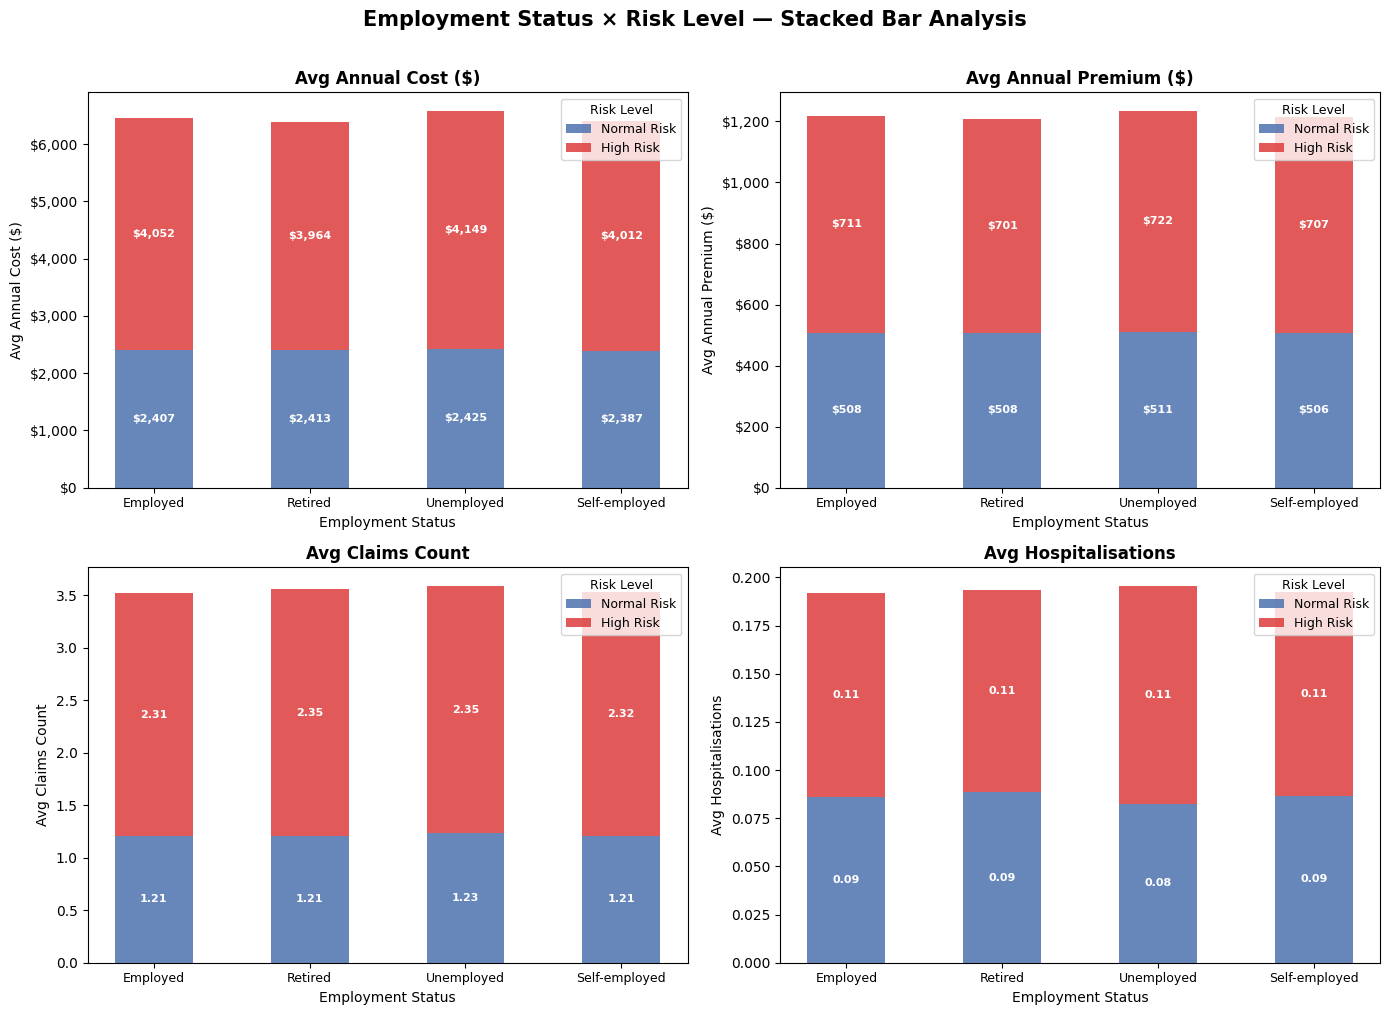

Saved: employment_risk_stacked_bar.png


In [7]:
# Metrics and style
metrics = {
    'Avg Annual Cost ($)':    'annual_medical_cost',
    'Avg Annual Premium ($)': 'annual_premium',
    'Avg Claims Count':       'claims_count',
    'Avg Hospitalisations':   'hospitalizations_last_3yrs',
}

emp_order   = ['Employed', 'Retired', 'Unemployed', 'Self-employed']
risk_labels = {0: 'Normal Risk', 1: 'High Risk'}
risk_colors = ['#4C72B0', '#DD3C3C']   # blue = normal, red = high

# Plot 2×2 grid of stacked bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Employment Status × Risk Level — Stacked Bar Analysis',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (title, col) in zip(axes.flat, metrics.items()):

    bottoms = np.zeros(len(emp_order))

    for risk_val, risk_label, color in zip([0, 1], risk_labels.values(), risk_colors):

        vals = (df[df['is_high_risk'] == risk_val]
                .groupby('employment_status')[col]
                .mean()
                .reindex(emp_order)
                .fillna(0)
                .values)

        bars = ax.bar(emp_order, vals,
                      bottom=bottoms,
                      label=risk_label,
                      color=color,
                      alpha=0.85,
                      width=0.5)

        # Label in the centre of each segment
        for bar, v, b in zip(bars, vals, bottoms):
            if v > 0:
                fmt = f'${v:,.0f}' if '$' in title else f'{v:.2f}'
                ax.text(bar.get_x() + bar.get_width() / 2, b + v / 2,
                        fmt, ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')

        bottoms += vals

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Employment Status')
    ax.set_ylabel(title)
    ax.set_xticklabels(emp_order, fontsize=9)
    ax.legend(title='Risk Level', fontsize=9, title_fontsize=9)

    if '$' in title:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.savefig('employment_risk_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: employment_risk_stacked_bar.png")

Here are some interesting takeaways from the charts:

* Retired patients stand out across every metric — highest total costs, premiums, claims count, and hospitalisations, driven by a much larger red (high risk) segment
* Unemployed patients have surprisingly similar costs to employed ones, but with a slightly higher proportion of high-risk cases
* Self-employed patients look the healthiest overall — lowest costs and fewest hospitalisations across both risk groups